# Dynamic Dataset Overview

Analisa o dataset em `dynamic/data` com estrutura por split:
- `data/<split>/frames/<word>/<video_id>/*.(jpg|jpeg|png)`
- `data/<split>/pose/<word>/<video_id>/*.(jpg|jpeg|png)`

Objetivos:
1. Contar palavras, vídeos e frames por split.
2. Identificar anomalias de estrutura.
3. Comparar cobertura entre `frames` e `pose`.

In [10]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

print('Python executable:', sys.executable)
print('Conda env:', os.environ.get('CONDA_DEFAULT_ENV'))

SPLITS = ['train', 'test', 'val']
VALID_EXTS = {'.jpg', '.jpeg', '.png'}


def resolve_data_root() -> Path:
    candidates = [
        Path('data'),
        Path('notebooks/dynamic/data'),
        Path('../dynamic/data'),
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Nao foi possivel localizar dynamic/data.')


DATA_ROOT = resolve_data_root()
OUTPUT_DIR = Path('output').resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_ROOT =', DATA_ROOT)
print('OUTPUT_DIR =', OUTPUT_DIR)


def list_frames(video_dir: Path) -> list[Path]:
    return sorted([p for p in video_dir.iterdir() if p.is_file() and p.suffix.lower() in VALID_EXTS])


def scan_branch(split: str, branch: str) -> pd.DataFrame:
    root = DATA_ROOT / split / branch
    rows = []
    if not root.exists():
        return pd.DataFrame(columns=['split', 'branch', 'word', 'video_id', 'n_frames'])

    for word_dir in sorted([d for d in root.iterdir() if d.is_dir()]):
        for video_dir in sorted([d for d in word_dir.iterdir() if d.is_dir()]):
            rows.append({
                'split': split,
                'branch': branch,
                'word': word_dir.name,
                'video_id': video_dir.name,
                'n_frames': len(list_frames(video_dir)),
            })

    return pd.DataFrame(rows)

frames_df = pd.concat([scan_branch(s, 'frames') for s in SPLITS], ignore_index=True)
pose_df = pd.concat([scan_branch(s, 'pose') for s in SPLITS], ignore_index=True)

summary = (
    pd.concat([frames_df, pose_df], ignore_index=True)
    .groupby(['split', 'branch'], as_index=False)
    .agg(
        n_words=('word', 'nunique'),
        n_videos=('video_id', 'count'),
        n_frames_total=('n_frames', 'sum'),
        mean_frames=('n_frames', 'mean'),
    )
)

frames_df.to_csv(OUTPUT_DIR / 'frames_detail.csv', index=False)
pose_df.to_csv(OUTPUT_DIR / 'pose_detail.csv', index=False)
summary.to_csv(OUTPUT_DIR / 'summary.csv', index=False)

summary

Python executable: /opt/miniconda3/envs/aslai-clean/bin/python
Conda env: aslai-clean
DATA_ROOT = /Users/nunoaraujo/MIA/SA/ASLAI--SA/TrabalhoPraticoNovo/notebooks/dynamic/data
OUTPUT_DIR = /Users/nunoaraujo/MIA/SA/ASLAI--SA/TrabalhoPraticoNovo/notebooks/dynamic/outputs_data_overview


,split,branch,n_words,n_videos,n_frames_total,mean_frames
0,test,frames,100,258,4128,16.0
1,test,pose,100,258,4128,16.0
2,train,frames,100,1440,23040,16.0
3,train,pose,100,1440,23040,16.0
4,val,frames,100,337,5392,16.0
5,val,pose,100,337,5392,16.0


Total pares: 2035
Divergencias: 0


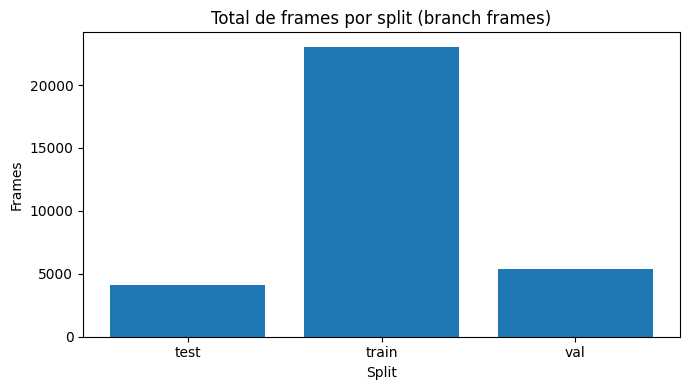


Resumo n_videos por palavra:
min=18, p25=18.8, mediana=19.5, media=20.35, p75=21.0, max=40


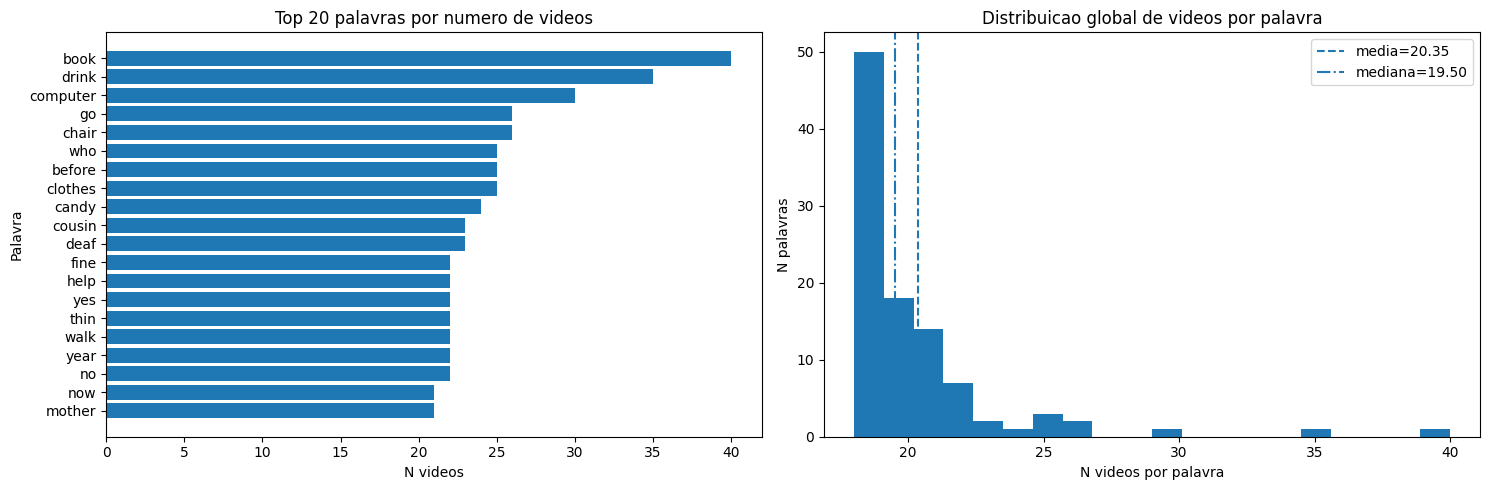

In [14]:
# Comparacao de cobertura frames vs pose
f = frames_df[['split', 'word', 'video_id', 'n_frames']].rename(columns={'n_frames': 'n_frames_frames'})
p = pose_df[['split', 'word', 'video_id', 'n_frames']].rename(columns={'n_frames': 'n_frames_pose'})
match = f.merge(p, how='outer', on=['split', 'word', 'video_id'])


def match_status(row: pd.Series) -> str:
    if pd.isna(row['n_frames_frames']):
        return 'missing_in_frames'
    if pd.isna(row['n_frames_pose']):
        return 'missing_in_pose'
    if int(row['n_frames_frames']) != int(row['n_frames_pose']):
        return 'count_mismatch'
    return 'ok'


match['match_status'] = match.apply(match_status, axis=1)
match.to_csv(OUTPUT_DIR / 'frames_pose_match.csv', index=False)

issues = match[match['match_status'] != 'ok']
print('Total pares:', len(match))
print('Divergencias:', len(issues))
if not issues.empty:
    display(issues.head(20))

# Visualizacao rapida
if not frames_df.empty:
    split_totals = frames_df.groupby('split', as_index=False)['n_frames'].sum()
    plt.figure(figsize=(7, 4))
    plt.bar(split_totals['split'], split_totals['n_frames'])
    plt.title('Total de frames por split (branch frames)')
    plt.xlabel('Split')
    plt.ylabel('Frames')
    plt.tight_layout()
    plt.show()

    videos_per_word = (
        frames_df.groupby('word', as_index=False)['video_id']
        .count()
        .rename(columns={'video_id': 'n_videos'})
        .sort_values('n_videos', ascending=False)
    )

    stats = videos_per_word['n_videos'].describe(percentiles=[0.25, 0.5, 0.75])
    print('\nResumo n_videos por palavra:')
    print(
        f"min={int(stats['min'])}, p25={stats['25%']:.1f}, "
        f"mediana={stats['50%']:.1f}, media={stats['mean']:.2f}, "
        f"p75={stats['75%']:.1f}, max={int(stats['max'])}"
    )

    top_n = 20
    top_words = videos_per_word.head(top_n).sort_values('n_videos', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].barh(top_words['word'], top_words['n_videos'])
    axes[0].set_title(f'Top {top_n} palavras por numero de videos')
    axes[0].set_xlabel('N videos')
    axes[0].set_ylabel('Palavra')

    axes[1].hist(videos_per_word['n_videos'], bins=20)
    axes[1].axvline(stats['mean'], linestyle='--', label=f"media={stats['mean']:.2f}")
    axes[1].axvline(stats['50%'], linestyle='-.', label=f"mediana={stats['50%']:.2f}")
    axes[1].set_title('Distribuicao global de videos por palavra')
    axes[1].set_xlabel('N videos por palavra')
    axes[1].set_ylabel('N palavras')
    axes[1].legend()

    plt.tight_layout()
    plt.show()